In [1]:
import pandas as pd
import numpy as np
import json
import os
from matplotlib import pyplot as plt
import joblib
import sys
sys.path.insert(0, '../models/shapenet')
import wrappers

In [2]:
CHANNEL_NAMES = ['BVP', 'EDA', 'ACC_X', 'ACC_Y', 'ACC_Z', 'Magnitude', 'HR', 'RMSSD', 'PHASIC', 'TONIC']
FS = 16

In [3]:
results_path = '../experiments/results/shapenet_tuning/'

In [4]:
trials = os.listdir(results_path)
trials = [t for t in trials if t.startswith('trial')]
print(f"{len(trials)} trials found:")
trials

30 trials found:


['trial_0',
 'trial_1',
 'trial_10',
 'trial_11',
 'trial_12',
 'trial_13',
 'trial_14',
 'trial_15',
 'trial_2',
 'trial_27',
 'trial_28',
 'trial_29',
 'trial_3',
 'trial_30',
 'trial_35',
 'trial_36',
 'trial_37',
 'trial_38',
 'trial_4',
 'trial_5',
 'trial_55',
 'trial_56',
 'trial_57',
 'trial_58',
 'trial_59',
 'trial_6',
 'trial_60',
 'trial_7',
 'trial_8',
 'trial_9']

In [5]:
incomplete_trials = []
for t in trials:
    val_results_path = f"{results_path}/{t}/session_model/session_model_val_results.json"
    if os.path.exists(val_results_path):
        with open(val_results_path, 'r') as file:
            val_results = json.load(file)
        val_auroc = val_results['auroc']
        val_auprc = val_results['auprc']
        print(f"{t}: val AUROC = {val_auroc}, val AUPRC = {val_auprc}")
    else:
        incomplete_trials.append(t)
        print(f"{t} does not have val results file!")

trial_0: val AUROC = 0.6068891891107128, val AUPRC = 0.2722665234873341
trial_1: val AUROC = 0.5379913915570097, val AUPRC = 0.23294020615974995
trial_10 does not have val results file!
trial_11: val AUROC = 0.6238885059467547, val AUPRC = 0.3000454264645296
trial_12: val AUROC = 0.5788175054993075, val AUPRC = 0.2522466475402637
trial_13 does not have val results file!
trial_14 does not have val results file!
trial_15: val AUROC = 0.5887804184252998, val AUPRC = 0.26243885704158454
trial_2: val AUROC = 0.46959799777773326, val AUPRC = 0.18678397670784733
trial_27: val AUROC = 0.6655566830405991, val AUPRC = 0.33136702572541094
trial_28 does not have val results file!
trial_29: val AUROC = 0.6528089481854045, val AUPRC = 0.3121906198564558
trial_3: val AUROC = 0.5436019522113466, val AUPRC = 0.22819665223174307
trial_30: val AUROC = 0.6400582826506113, val AUPRC = 0.2905216679143296
trial_35: val AUROC = 0.5793624766424836, val AUPRC = 0.2518278982960882
trial_36 does not have val resu

In [6]:
best_trial = 'trial_27'
best_trial_test_file = f"{results_path}/{best_trial}/session_model/session_model_results.json"
if os.path.exists(best_trial_test_file):
    with open(best_trial_test_file, 'r') as file:
        best_test_results = json.load(file)
    best_test_auroc = best_test_results['auroc']
    best_test_auprc = best_test_results['auprc']
    print(f"Best trial {best_trial}: test AUROC = {best_test_auroc}, test AUPRC = {best_test_auprc}")

Best trial trial_27: test AUROC = 0.668615793653984, test AUPRC = 0.35023758516888237


In [7]:
best_trial_param_file = f"{results_path}/{best_trial}/trial_params.json"
with open(best_trial_param_file, 'r') as file:
    best_params = json.load(file)
print(best_params)

{'trial_number': 50, 'params': {'batch_size': 128, 'channels': 10, 'depth': 5, 'reduced_size': 80, 'out_channels': 160, 'kernel_size': 2, 'epochs': 200, 'lr': 0.00010015714823947611, 'final_shapelet_num': 50, 'compared_length': None}, 'resumed_from': 'trial_27'}


Text(0, 0.5, 'loss')

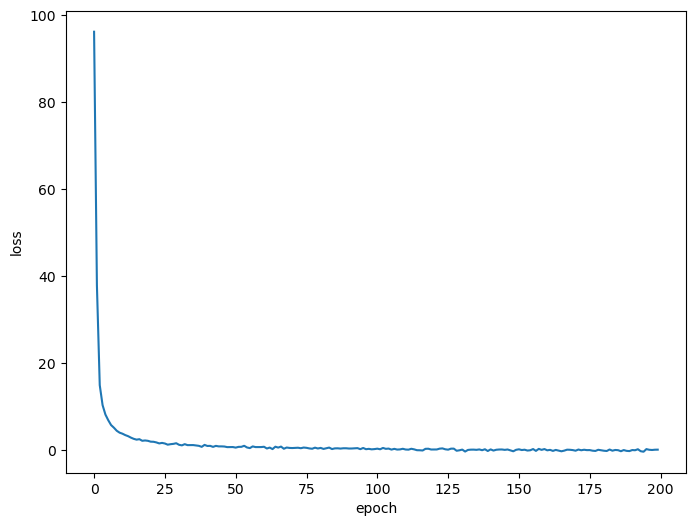

In [8]:
loss_path = '../experiments/results/shapenet/session_model_full/session_model_loss_history.npy'
loss_history = np.load(loss_path)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
ax.plot(loss_history)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")

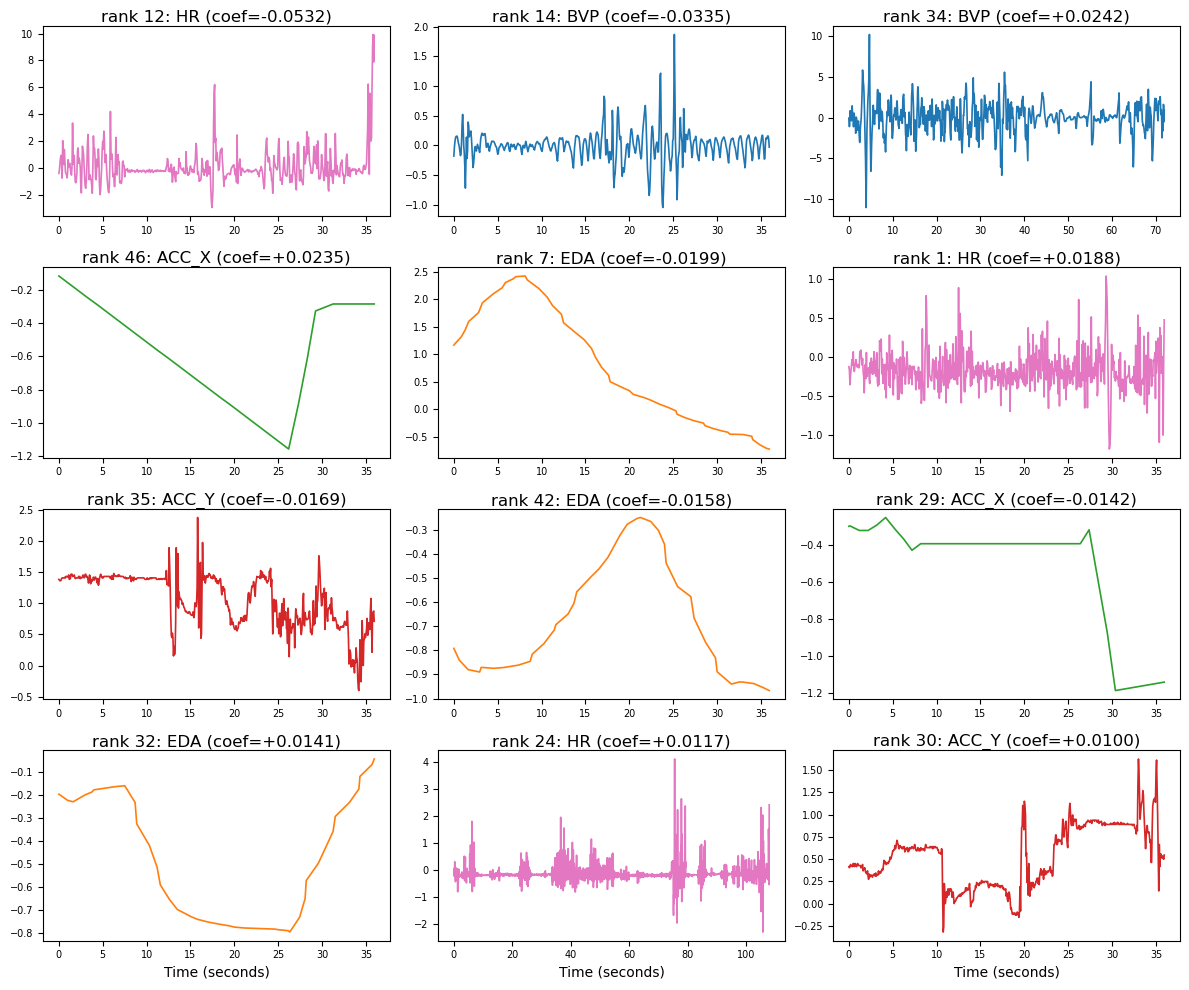

In [24]:
cmap = plt.get_cmap("tab10")
channel_colors = {name: cmap(i % 10) for i, name in enumerate(CHANNEL_NAMES)}

def load_shapelets(trial_dir):
    """Load shapelet array, dim array, and utility sort index from .npz cache."""
    npz_path = os.path.join(trial_dir, "session_model", "session_model_shapelets.npz")
    if not os.path.exists(npz_path):
        return None
    data = np.load(npz_path, allow_pickle=True)
    shapelet = list(data["shapelet"])                   # list of 1-D arrays
    shapelet_dim = data["shapelet_dim"].tolist()        # channel index per candidate
    utility_sort_index = data["utility_sort_index"]     # candidates sorted best to worst
    return shapelet, shapelet_dim, utility_sort_index

def plot_trial_shapelets(trial_name, trial_dir, results_path,
                         max_shapelets=None, ax_width=4, ax_height=2.5, 
                         classifier=None, sort_by_importance=False):
    """Plot top shapelets for one trial, each coloured by channel."""
    loaded = load_shapelets(trial_dir)
    if loaded is None:
        print(f"[skip] {trial_name}: shapelets.npz not found")
        return

    coef = np.array([])
    if classifier is not None:
        clf = wrappers.CausalCNNEncoderClassifier(cuda=True, gpu=0, final_shapelet_num=12)
        clf.classifier = classifier
        coef = clf.classifier.coef_.to_output('numpy').flatten()  # (n_shapelets,)

    shapelet, shapelet_dim, utility_sort_index = loaded

    # final_shapelet_num from results.json (= len(shapelet_info))
    with open(results_path) as f:
        r = json.load(f)
    si_list = r.get("shapelet_info", [])
    n_final = len(si_list) if max_shapelets is None else min(max_shapelets, len(si_list))
    auroc = r.get("auroc", float("nan"))

    nrows = int(np.ceil(n_final / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(ax_width * 3, ax_height * nrows), sharex=False)
    if n_final == 1:
        axes = [axes]

    axes = axes.flatten()

    order = range(n_final)

    if sort_by_importance:
        assert classifier is not None
        order = np.argsort(-np.abs(coef))

def plot_trial_shapelets(trial_name, trial_dir, results_path,
                         max_shapelets=None, ax_width=4, ax_height=2.5, 
                         classifier=None, sort_by_importance=False):
    """Plot top shapelets for one trial, each coloured by channel."""
    loaded = load_shapelets(trial_dir)
    if loaded is None:
        print(f"[skip] {trial_name}: shapelets.npz not found")
        return

    coef = np.array([])
    if classifier is not None:
        clf = wrappers.CausalCNNEncoderClassifier(cuda=True, gpu=0, final_shapelet_num=12)
        clf.classifier = classifier
        coef = clf.classifier.coef_.to_output('numpy').flatten()  # (n_shapelets,)

    shapelet, shapelet_dim, utility_sort_index = loaded

    # final_shapelet_num from results.json (= len(shapelet_info))
    with open(results_path) as f:
        r = json.load(f)
    si_list = r.get("shapelet_info", [])
    n_final = len(si_list) if max_shapelets is None else min(max_shapelets, len(si_list))
    auroc = r.get("auroc", float("nan"))

    nrows = int(np.ceil(n_final / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(ax_width * 3, ax_height * nrows), sharex=False)
    if n_final == 1:
        axes = [axes]

    axes = axes.flatten()

    order = range(n_final)

    if sort_by_importance:
        assert classifier is not None
        order = np.argsort(-np.abs(coef))

    order = order[:max_shapelets]

    for plot_rank, shapelet_rank in enumerate(order):
        idx = utility_sort_index[shapelet_rank]
        ch = int(shapelet_dim[idx])
        ch_name = CHANNEL_NAMES[ch] if ch < len(CHANNEL_NAMES) else f"ch{ch}"
        wave = np.asarray(shapelet[idx])
        time = np.arange(len(wave)) / FS
        color = channel_colors.get(ch_name, "grey")
        c = f" (coef={coef[shapelet_rank]:+.4f})" if len(coef) > 0 else ""

        ax = axes[plot_rank]
        ax.plot(time, wave, color=color, linewidth=1.2)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_title(f"rank {shapelet_rank}: {ch_name}{c}", rotation=0, va="center")
        if np.ceil((plot_rank + 1) / 3) == nrows:
            ax.set_xlabel("Time (seconds)")

    suffix = '_sort_by_importance' if sort_by_importance else ''
    plt.tight_layout()
    plt.savefig(f"{trial_name}_selected_shapelets{suffix}.png")
    plt.show()

classifier_path = f'{results_path}/{best_trial}/session_model/session_model_CausalCNN_classifier.pkl'
classifier = joblib.load(classifier_path)

# Plot every trial that has both results.json and shapelets.npz
plot_trial_shapelets(
    best_trial, 
    f"{results_path}/{best_trial}", 
    best_trial_test_file, 
    max_shapelets=12,
    classifier=classifier,
    sort_by_importance=True,
)

In [ ]:
import json, joblib, numpy, torch
import sys
sys.path.insert(0, 'models/shapenet')
import wrappers

prefix = 'experiments/results/shapenet/.../session_model/session_model'

# 1. パラメータ読み込みとモデル構築
with open(prefix + '_parameters.json') as f:
    params = json.load(f)

clf = wrappers.CausalCNNEncoderClassifier()
params['cuda'] = True  # or False
params['gpu'] = 0
clf.set_params(**params)

# 2. encoder と SVM をロード
clf.load_encoder(prefix)
clf.classifier = joblib.load(prefix + '_svm.joblib')

# 3. shapelets をロード
data = numpy.load(prefix + '_shapelets.npz', allow_pickle=True)
shapelet = list(data['shapelet'])
shapelet_dim = list(data['shapelet_dim'])
utility_sort_index = data['utility_sort_index']
final_shapelet_num = params['final_shapelet_num']

# 4. inference
# X: shape (N, C, T) の numpy array
features = clf._get_features(X, shapelet, shapelet_dim, utility_sort_index, final_shapelet_num)
y_pred = clf.classifier.predict(features)
